In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine  # Changed from load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names  # Represents class_0, class_1, class_2


In [10]:
print(list(X[0]), "---->", y[0])
print(list(X[69]), "---->", y[69])

print(target_names)

[14.23, 1.71, 2.43, 15.6, 127.0, 2.8, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0] ----> 0
[12.21, 1.19, 1.75, 16.8, 151.0, 1.85, 1.28, 0.14, 2.5, 2.85, 1.28, 3.07, 718.0] ----> 1
['class_0' 'class_1' 'class_2']


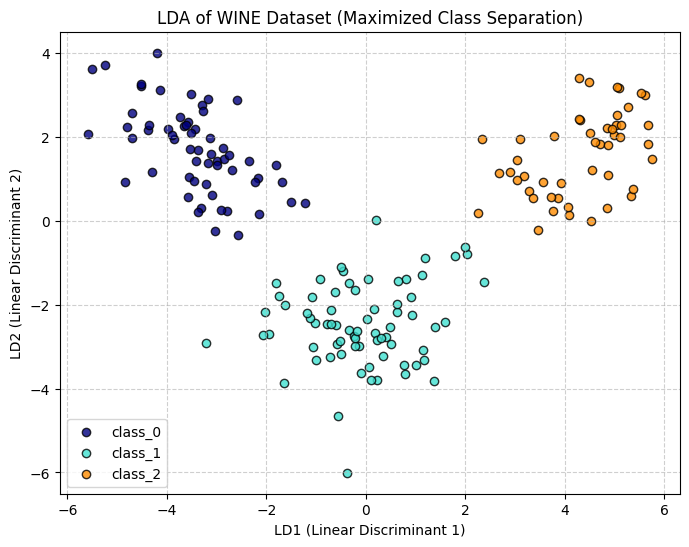

In [3]:

# 2. Apply LDA (Reduce from 13 dimensions to 2)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

# 3. Plot the result
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color,
                label=target_name, edgecolors='k')

plt.title('LDA of WINE Dataset (Maximized Class Separation)')  # Updated title
plt.xlabel('LD1 (Linear Discriminant 1)')
plt.ylabel('LD2 (Linear Discriminant 2)')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# Part2: Application  of LDA

In [14]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# 1. Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# 2. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Build a pipeline: Scale -> LDA (Reduce to 2D) -> Logistic Regression
# (StandardScaler is added here as best practice for the Logistic Regression step)
model_pipeline = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(n_components=2),
    LogisticRegression(random_state=42),
)

# 4. Train the model
model_pipeline.fit(X_train, y_train)

# 5. Evaluate the model
accuracy = model_pipeline.score(X_test, y_test)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%")

# 6. Predict a new unseen wine sample
# Dummy sample with 13 features matching the Wine dataset structure
new_wine_sample = np.array(
    [[14.23, 1.71, 2.43, 15.6, 127.0, 2.8, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0]] # =X[0], actual y[0] = 0
)

# new_wine_sample = np.array(
#     [[12.21, 1.19, 1.75, 16.8, 151.0, 1.85, 1.28, 0.14, 2.5, 2.85, 1.28, 3.07, 718.0]] # =X[69], actual y[69] = 1
# )


predicted_class = model_pipeline.predict(new_wine_sample)
print(f"Predicted Cultivator: Class {predicted_class[0]} ({wine.target_names[predicted_class[0]]})")


Model Accuracy on Test Set: 97.22%
Predicted Cultivator: Class 0 (class_0)
